In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()
df.shape

(200, 2)

Text(0, 0.5, 'Package(in lpa)')

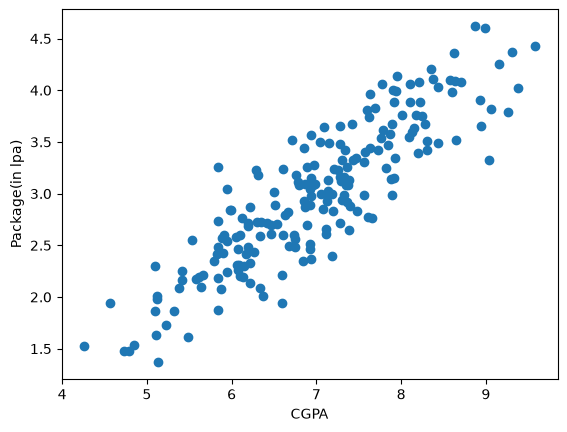

In [4]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [5]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [6]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.56]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.8961
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Text(0, 0.5, 'Package(in lpa)')

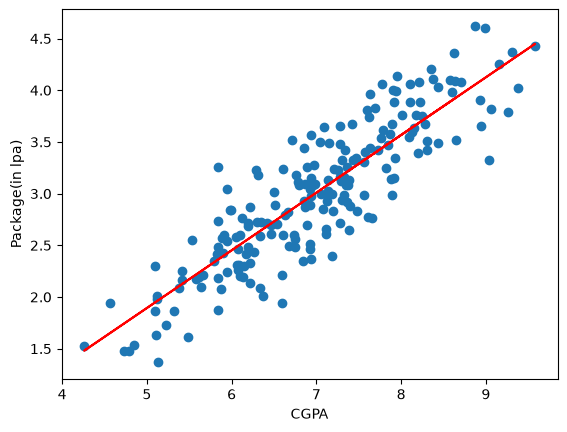

In [11]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [12]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score  

In [16]:
y_pred = lr.predict(X_test)
y_pred

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [15]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [26]:
my_mae = mean_absolute_error( y_test , y_pred )
print('MAE: ', my_mae)

MAE:  0.2884710931878175


In [28]:
my_mse = mean_squared_error(y_test , y_pred)
print('MSE: ', my_mse)

MSE:  0.12129235313495527


In [30]:
my_rmse = root_mean_squared_error(y_test , y_pred)
print('RMSE: ',my_rmse)

RMSE:  0.34827051717731616


In [32]:
my_r2 = r2_score(y_test , y_pred)
print('R2_score: ', my_r2)

R2_score:  0.780730147510384


In [ ]:
# Adjusted R2 score

# adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))


In [33]:
X_test.shape

(40, 1)

In [35]:
my_ad_r2 = 1 - ((1 - my_r2) * (40 - 1) / (40 - 1 - 1))
my_ad_r2

0.7749598882343415

In [37]:
# more dinemic

1 - ((1 - my_r2) * (X_test.shape[0] - 1) / (X_test.shape[0] - X_test.shape[1] - 1))

0.7749598882343415

In [38]:

# A new column - a random feature(not relevent to the package column)

new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.830239,3.26
1,5.12,0.705291,1.98
2,7.82,0.153698,3.25
3,7.42,0.566427,3.67
4,6.94,0.901652,3.57


Text(0, 0.5, 'Package(in lpa)')

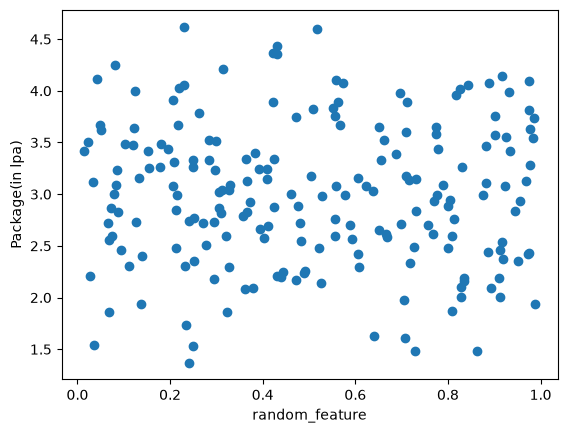

In [39]:

plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')


In [40]:

X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]


In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [42]:
lr = LinearRegression()


In [43]:
lr.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.56,0.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['cgpa','random_feature']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.9126
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [44]:
y_pred = lr.predict(X_test)
y_pred

array([3.89301535, 3.08220733, 2.38020816, 2.57973703, 1.66586969,
       1.78166748, 2.0595511 , 2.91978081, 3.7579743 , 2.93140459,
       4.09656649, 3.50155757, 2.96954547, 2.40225627, 3.19548745,
       3.457675  , 1.9380989 , 3.24558932, 2.98717504, 3.40363547,
       2.55761602, 3.17310554, 2.86692229, 3.11729511, 3.68684467,
       2.85793528, 3.50249813, 3.35720787, 3.93228609, 1.96861303,
       3.66435306, 3.20683652, 3.73519527, 2.77607256, 2.76752331,
       3.26962713, 3.52480176, 2.60156288, 2.66880519, 2.71791267])

In [49]:
new_r2 = r2_score(y_test , y_pred)
print('new r2 score: ', new_r2)
print('old r2 score: ', my_r2)

# new r2 score is increased , which is not desirsable

new r2 score:  0.7811395568261194
old r2 score:  0.780730147510384


In [53]:
new_ad_r2 = 1 - ((1 - new_r2) * (40 - 1 ) / (40 - 1 - 2))
print('new adjusted r2:' ,new_ad_r2)
print('old adjusted r2:' ,my_ad_r2)

# adjusted r2 decreased a little 

new adjusted r2: 0.7693092626005041
old adjusted r2: 0.7749598882343415


In [54]:
# Adding a relevent column to package


new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

In [55]:
new_df2.sample(5)


,cgpa,iq,package
46,6.07,1.86,2.26
66,5.11,1.63,1.63
20,7.28,3.76,3.16
81,6.10,1.20,2.20
187,6.26,2.64,2.44


Text(0, 0.5, 'Package(in lpa)')

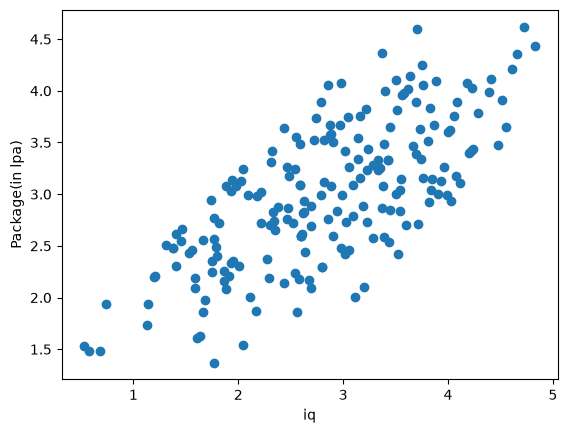

In [56]:

plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [58]:
np.random.randint(-100,100)


62

In [59]:

X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [60]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [61]:

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [67]:
new_r2 = r2_score(y_test , y_pred)
print('New r2 score',new_r2)
print('Old r2 score',my_r2)

# increased r2 , which is good

New r2 score 0.841920615630191
Old r2 score 0.780730147510384


In [69]:
new_ad_r2 = 1 - ((1-new_r2)*(40-1)/(40-1-2))
print('New adjusted r2 score',new_ad_r2)
print('Old adjusted r2 score',my_ad_r2)

# adjusted also increased

New adjusted r2 score 0.8333757840426338
Old adjusted r2 score 0.7749598882343415
